# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [52]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("/content/CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          2500 non-null   object 
 1   Genero              2488 non-null   object 
 2   Idoso               2500 non-null   int64  
 3   Casado              2500 non-null   object 
 4   Dependents          2500 non-null   object 
 5   Tempo_como_Cliente  2500 non-null   int64  
 6   PhoneService        1018 non-null   object 
 7   Servico_Internet    2500 non-null   object 
 8   Servico_Seguranca   2500 non-null   object 
 9   Suporte_Tecnico     2500 non-null   object 
 10  StreamingTV         2500 non-null   object 
 11  Tipo_Contrato       2500 non-null   object 
 12  PaymentMethod       2500 non-null   object 
 13  Pagamento_Mensal    2175 non-null   float64
 14  Total_Pago          2500 non-null   float64
 15  Churn               2495 non-null   object 
dtypes: flo

In [54]:
# transformar ID em string
df['customerID'] = df['customerID'].astype('string')

# colunas categóricas
categoricas = [
    'Genero',
    'Casado',
    'Dependents',
    'PhoneService',
    'Servico_Internet',
    'Servico_Seguranca',
    'Suporte_Tecnico',
    'StreamingTV',
    'Tipo_Contrato',
    'PaymentMethod',
    'Churn'
]

df[categoricas] = df[categoricas].astype('category')

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   customerID          2500 non-null   string  
 1   Genero              2488 non-null   category
 2   Idoso               2500 non-null   int64   
 3   Casado              2500 non-null   category
 4   Dependents          2500 non-null   category
 5   Tempo_como_Cliente  2500 non-null   int64   
 6   PhoneService        1018 non-null   category
 7   Servico_Internet    2500 non-null   category
 8   Servico_Seguranca   2500 non-null   category
 9   Suporte_Tecnico     2500 non-null   category
 10  StreamingTV         2500 non-null   category
 11  Tipo_Contrato       2500 non-null   category
 12  PaymentMethod       2500 non-null   category
 13  Pagamento_Mensal    2175 non-null   float64 
 14  Total_Pago          2500 non-null   float64 
 15  Churn               2495 non-null   ca

# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [56]:
# quantidade de valores nulos por coluna
nulos = df.isnull().sum()

# porcentagem de valores nulos
percentual_nulos = (df.isnull().sum() / len(df)) * 100

# criar tabela resumo
dados_faltantes = pd.DataFrame({
    'Valores_Nulos': nulos,
    'Percentual (%)': percentual_nulos
})

dados_faltantes

,Valores_Nulos,Percentual (%)
customerID,0,0.00
Genero,12,0.48
Idoso,0,0.00
Casado,0,0.00
Dependents,0,0.00
Tempo_como_Cliente,0,0.00
PhoneService,1482,59.28
Servico_Internet,0,0.00
Servico_Seguranca,0,0.00
Suporte_Tecnico,0,0.00


B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [57]:
# remover linhas com valores nulos em Genero e Churn
df = df.dropna(subset=['Genero', 'Churn', "PhoneService", ])

# verificar novamente
df.isnull().sum()

,0
customerID,0
Genero,0
Idoso,0
Casado,0
Dependents,0
Tempo_como_Cliente,0
PhoneService,0
Servico_Internet,0
Servico_Seguranca,0
Suporte_Tecnico,0


- remover PhoneService eliminaria mais da metade do dataset

- Pagamento_Mensal ainda pode ser tratado por imputação.

In [58]:
df.shape

(1006, 16)

C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

In [59]:
# verificar média e mediana
print("Média:", df['Pagamento_Mensal'].mean())
print("Mediana:", df['Pagamento_Mensal'].median())

Média: 64.7914534883721
Mediana: 70.55


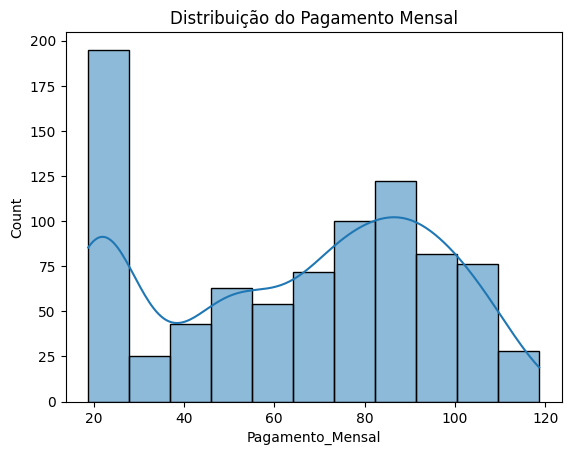

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Pagamento_Mensal'], kde=True)
plt.title("Distribuição do Pagamento Mensal")
plt.show()

In [61]:
# substituir nulos de Pagamento_Mensal pela mediana
df['Pagamento_Mensal'] = df['Pagamento_Mensal'].fillna(df['Pagamento_Mensal'].median())

In [62]:
df['Pagamento_Mensal'].isnull().sum()

np.int64(0)

In [64]:
df.isnull().sum()

,0
customerID,0
Genero,0
Idoso,0
Casado,0
Dependents,0
Tempo_como_Cliente,0
PhoneService,0
Servico_Internet,0
Servico_Seguranca,0
Suporte_Tecnico,0


Os valores faltantes da variável Pagamento_Mensal foram substituídos pela mediana, pois a distribuição da variável apresenta assimetria e a mediana é menos sensível a valores extremos. Já a coluna PhoneService foi removida da base de dados, pois apresentava aproximadamente 59% de valores ausentes, o que poderia comprometer a qualidade da análise caso fosse realizada imputação.

# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [65]:
for col in df.select_dtypes(include='category'):
    print(col)
    print(df[col].unique())
    print()

Genero
['Female', 'Male', 'F', 'M', 'f']
Categories (5, object): ['F', 'Female', 'M', 'Male', 'f']

Casado
['Yes', 'No']
Categories (2, object): ['No', 'Yes']

Dependents
['No', 'Yes']
Categories (2, object): ['No', 'Yes']

PhoneService
['No', 'Yes']
Categories (2, object): ['No', 'Yes']

Servico_Internet
['DSL', 'No', 'Fiber optic', 'dsl']
Categories (4, object): ['DSL', 'Fiber optic', 'No', 'dsl']

Servico_Seguranca
['No', 'Yes', 'No internet service']
Categories (3, object): ['No', 'No internet service', 'Yes']

Suporte_Tecnico
['No', 'Yes', 'No internet service']
Categories (3, object): ['No', 'No internet service', 'Yes']

StreamingTV
['No', 'No internet service', 'Yes']
Categories (3, object): ['No', 'No internet service', 'Yes']

Tipo_Contrato
['Month-to-month', 'One year', 'Two year']
Categories (3, object): ['Month-to-month', 'One year', 'Two year']

PaymentMethod
['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Categories (4, object

In [67]:
for col in df.select_dtypes(include='category').columns:
    df[col] = df[col].astype(str).str.lower().astype('category')

In [68]:
df['Genero'] = df['Genero'].replace({
    'f': 'female',
    'm': 'male'
})

In [69]:
for col in df.select_dtypes(include='category'):
    print(col)
    print(df[col].unique())
    print()

Genero
['female', 'male']
Categories (2, object): ['female', 'male']

Casado
['yes', 'no']
Categories (2, object): ['no', 'yes']

Dependents
['no', 'yes']
Categories (2, object): ['no', 'yes']

PhoneService
['no', 'yes']
Categories (2, object): ['no', 'yes']

Servico_Internet
['dsl', 'no', 'fiber optic']
Categories (3, object): ['dsl', 'fiber optic', 'no']

Servico_Seguranca
['no', 'yes', 'no internet service']
Categories (3, object): ['no', 'no internet service', 'yes']

Suporte_Tecnico
['no', 'yes', 'no internet service']
Categories (3, object): ['no', 'no internet service', 'yes']

StreamingTV
['no', 'no internet service', 'yes']
Categories (3, object): ['no', 'no internet service', 'yes']

Tipo_Contrato
['month-to-month', 'one year', 'two year']
Categories (3, object): ['month-to-month', 'one year', 'two year']

PaymentMethod
['electronic check', 'mailed check', 'bank transfer (automatic)', 'credit card (automatic)']
Categories (4, object): ['bank transfer (automatic)', 'credit car

# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [70]:
df = df.rename(columns={
    'Genero': 'gender',
    'Idoso': 'senior_citizen',
    'Casado': 'married',
    'Dependents': 'dependents',
    'Tempo_como_Cliente': 'tenure_months',
    'PhoneService': 'phone_service',
    'Servico_Internet': 'internet_service',
    'Servico_Seguranca': 'security_service',
    'Suporte_Tecnico': 'technical_support',
    'StreamingTV': 'streaming_tv',
    'Tipo_Contrato': 'contract_type',
    'PaymentMethod': 'payment_method',
    'Pagamento_Mensal': 'monthly_payment',
    'Total_Pago': 'total_paid',
    'Churn': 'churn'
})

In [71]:
df.columns

Index(['customerID', 'gender', 'senior_citizen', 'married', 'dependents',
       'tenure_months', 'phone_service', 'internet_service',
       'security_service', 'technical_support', 'streaming_tv',
       'contract_type', 'payment_method', 'monthly_payment', 'total_paid',
       'churn'],
      dtype='object')